# Synthetic Object Detection

Find a character in a cluttered image and predict its bounding box. This project
creates its own labels by compositing one transparent object onto each background,
then compares a custom ResNet18 detector with YOLOv8n.

The experiment uses three fixed cut-outs: Waldo, Wenda and Wizard Whitebeard.
Background sources are separated before images are generated, so a held-out scene
cannot reuse an exact training background. This measures generalization to new
backgrounds, not to unseen character artwork or real photographs.

The notebook runs the experiment and writes the figures and JSON used by the
Quarto report. Reusable implementation lives in `src/detection.py`.

**Run status:** this revision needs a fresh character-data benchmark. Historical
scores are excluded because the original evaluation omitted class 0. An explicit
`smoke` mode exercises the notebook on geometric fixtures; it does not measure
character detection performance.

## Environment and configuration

Open this notebook from a checkout of the repository. Install dependencies with
`python -m pip install -r requirements.txt` using the notebook's Python environment.
For Colab, see `COLAB.md`; the repository is currently private.

`experiment` uses the character assets and 5,000 / 1,000 / 200 images. `pilot`
executes both models on 96 / 24 / 24 character images (two custom epochs and one
YOLO epoch) to check the real-data pipeline. It is not the full benchmark. `smoke`
uses 24 / 6 / 6 small generated fixtures and two epochs, without weight downloads.
The two modes write to separate directories. Set `DETECTION_RUN_MODE=smoke` before
starting Jupyter for an execution check, or change `RUN_MODE` below.

In [1]:
import json
import os
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src' / 'detection.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook inside the synthetic-object-detection checkout.')
sys.path[:0] = [str(ROOT / 'src'), str(ROOT / 'scripts')]

import matplotlib.pyplot as plt
import torch
from detection import (NAMES, ObjectDetectionDataset, generate_dataset,
                       seed_everything, train, train_yolo, write_json)
from visualization import plot_samples, plot_history

RUN_MODE = os.environ.get('DETECTION_RUN_MODE', 'experiment')
if RUN_MODE not in {'experiment', 'smoke', 'pilot'}:
    raise ValueError('RUN_MODE must be experiment, pilot or smoke')
SMOKE = RUN_MODE == 'smoke'
PILOT = RUN_MODE == 'pilot'
SEED = 42
EPOCHS = 2 if SMOKE or PILOT else 20
COUNTS = (24, 6, 6) if SMOKE else ((96, 24, 24) if PILOT else (5000, 1000, 200))
IMAGE_SIZE = 64 if SMOKE else 640
INPUT_SIZE = 64 if SMOKE else 224
BATCH_SIZE = 6 if SMOKE else 16
RUN_YOLO = not SMOKE
RESUME = False
REUSE_YOLO = True  # The independent YOLO run can be reused when its data/settings match.
DATASET = ROOT / 'data' / (RUN_MODE + '-generated-v2')
RUN_DIR = ROOT / 'outputs' / 'models' / (RUN_MODE + '-v3')
ARTIFACT_DIR = ROOT / 'outputs' / ('validation' if SMOKE else ('pilot' if PILOT else 'metrics'))
FIGURE_DIR = ARTIFACT_DIR / 'figures' if SMOKE or PILOT else ROOT / 'outputs/figures'
seed_everything(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
print({'mode': RUN_MODE, 'torch': torch.__version__, 'cuda': torch.cuda.is_available(),
       'counts': COUNTS, 'epochs': EPOCHS})

{'mode': 'smoke', 'torch': '2.14.0+cpu', 'cuda': False, 'counts': (24, 6, 6), 'epochs': 2}


## Object cut-outs and backgrounds

The approved replacement PNGs (`Waldo.png`, `Wenda.png`, and
`Wizard Whitebeard.png`) are saved in `assets/objects/`, with backgrounds in
`assets/backgrounds/`. `DATA.md` records source links and preparation
steps. The run fails on missing or empty assets instead of silently skipping
classes or generating unlabeled images.

Geometric fixtures below are used only when `RUN_MODE == 'smoke'`. Their filenames
reuse the three class slots to test the same code; they are not character artwork.

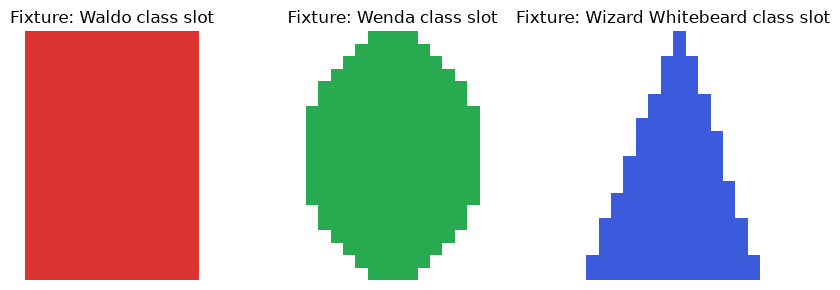

In [2]:
if SMOKE:
    from smoke_assets import create_assets
    objects_dir, backgrounds_dir = create_assets(ROOT / 'data' / 'smoke-assets')
else:
    objects_dir, backgrounds_dir = ROOT / 'assets/objects', ROOT / 'assets/backgrounds'

from PIL import Image
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, name in zip(axes, NAMES):
    with Image.open(objects_dir / f'{name}.png') as image:
        ax.imshow(image)
    ax.set_title(name if not SMOKE else f'Fixture: {name} class slot')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Synthetic supervision

Each source background belongs to exactly one split. Decoded pixel hashes remove
exact duplicates, and the manifest records the source for every composite.
Near-duplicate backgrounds still require review. The class counts are balanced to
within one image. Cut-outs keep their original size and aspect ratio.

Alpha compositing handles partially transparent edges. The box tightly encloses
the nontransparent cut-out and is stored as normalized `(cx, cy, width, height)`:

$$[(x+w/2)/W,\ (y+h/2)/H,\ w/W,\ h/H].$$

A horizontal training flip updates `cx` to `1-cx`. Validation and test inputs are
deterministic. Both custom-model splits use the same input resolution and ImageNet
normalization. Each image must have exactly one valid box, including class 0.

{'train': 16, 'val': 2, 'test': 2}


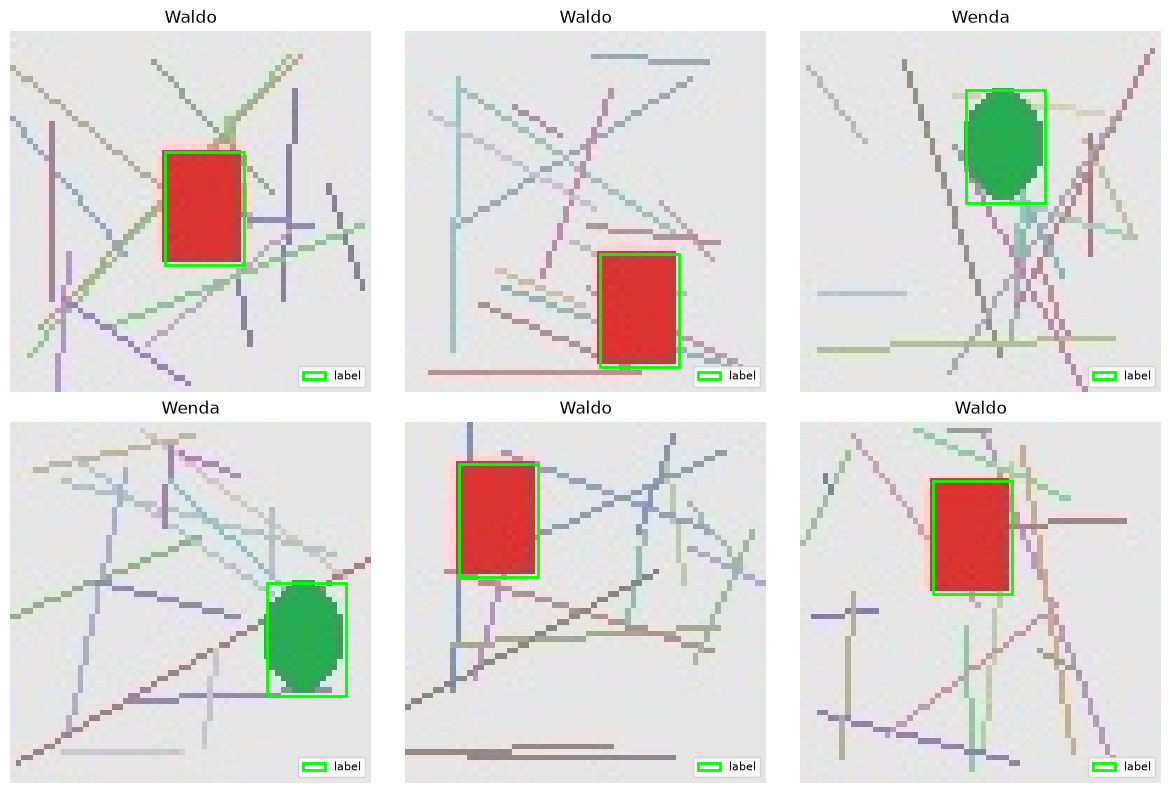

In [3]:
if not DATASET.exists():
    manifest = generate_dataset(objects_dir, backgrounds_dir, DATASET,
                                counts=COUNTS, size=IMAGE_SIZE, seed=SEED)
else:
    manifest = json.loads((DATASET / 'manifest.json').read_text())
    expected = dict(zip(['train', 'val', 'test'], COUNTS))
    if manifest['counts'] != expected or manifest['seed'] != SEED or manifest['size'] != IMAGE_SIZE:
        raise ValueError('Existing dataset configuration differs; choose a new dataset directory.')
print({split: len(rows) for split, rows in manifest['backgrounds'].items()})
sample_dataset = ObjectDetectionDataset(DATASET, 'train', size=INPUT_SIZE)
plot_samples(sample_dataset, FIGURE_DIR / 'dataset-samples.png')
plt.show()

## A custom detector

An ImageNet-pretrained ResNet18 produces the features. A pooled classification
head predicts three logits; cross-entropy operates on those logits directly.
The box head retains a `4 × 4` spatial grid instead of pooling every location
into one vector. This is an explicit architecture change from the original run.

Four sigmoid outputs parameterize box size and position. Centers are constrained
by the predicted width and height so the entire box remains inside the image.
Layer normalization and small final-layer weights keep the box sigmoid from
saturating during the first updates; initialization starts near a centered
20%-size box. This was added after the first real-data pilot revealed collapsed widths.
The loss is cross-entropy plus five times Smooth L1 on normalized boxes.

AdamW trains the whole network at `1e-4`, with `1e-4` weight decay. The best
validation loss selects the checkpoint; five epochs without improvement stop
training. Epoch losses are weighted by sample count. Resume checkpoints include
optimizer state, random-generator states, loss history and dataset identity.
Only load checkpoints produced by this project or another trusted source.

Epoch 1: train=1.21999, val=1.14816


Epoch 2: train=1.09736, val=1.13540


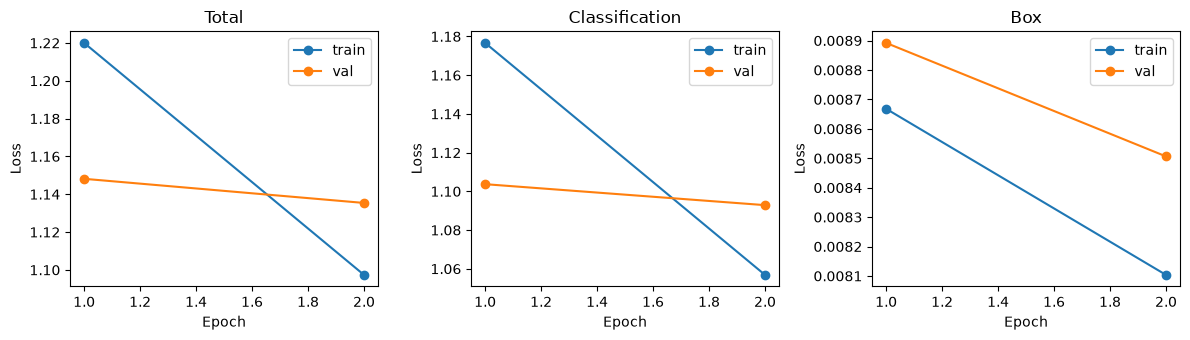

In [4]:
model, history, metrics = train(DATASET, RUN_DIR, epochs=EPOCHS,
    batch_size=BATCH_SIZE, size=INPUT_SIZE, seed=SEED,
    pretrained=not SMOKE, resume=RESUME)
metrics['run_mode'] = RUN_MODE
metrics['benchmark_result'] = RUN_MODE == 'experiment'
write_json(ARTIFACT_DIR / 'test_results.json', metrics)
write_json(ARTIFACT_DIR / 'training_history.json', history)
plot_history(history, FIGURE_DIR / 'loss-curves.png')
plt.show()

## Held-out evaluation

A correct detection has the correct class and IoU **at least 0.5**. The custom
model always emits one box, so precision and recall must be equal here. Mean IoU
measures localization independently of class. A missing YOLO prediction receives
zero IoU and still contributes a ground truth to recall.

AP50 ranks detections by confidence and integrates the all-points interpolated
precision-recall curve. It is named `map50_all_points` to distinguish it from
Ultralytics' native AP implementation. Latency is a warmed, synchronized forward
pass divided by image count; it excludes I/O, transfers and postprocessing.

EXECUTION CHECK — not the full benchmark
{
  "samples": 6,
  "predictions": 6,
  "true_positives": 0,
  "precision": 0.0,
  "recall": 0.0,
  "f1": 0.0,
  "class_accuracy": 0.16666666666666666,
  "mean_iou": 0.1169511726194012,
  "map50_all_points": 0.0,
  "ap50_by_class": {
    "Waldo": 0.0,
    "Wenda": 0.0,
    "Wizard Whitebeard": 0.0
  },
  "iou_threshold": 0.5,
  "protocol": "one-top-confidence-box-per-image",
  "forward_ms_per_image": 6.9551500000670785,
  "timing_scope": "warm forward only; excludes loading, transfers and postprocessing",
  "device": "cpu",
  "config": {
    "dataset_sha256": "31ab214f9a8f8756bad07eaa9f03744b5f6ec88d8db96732f8e45b338e03242f",
    "size": 64,
    "seed": 42,
    "pretrained": false,
    "batch_size": 6,
    "patience": 5,
    "architecture": "resnet18-spatial4-layernorm-validbox-v2"
  },
  "epochs_completed": 2,
  "selected_epoch": 2,
  "parameters": 13423431,
  "torch_version": "2.14.0+cpu",
  "run_mode": "smoke",
  "benchmark_result": false
}


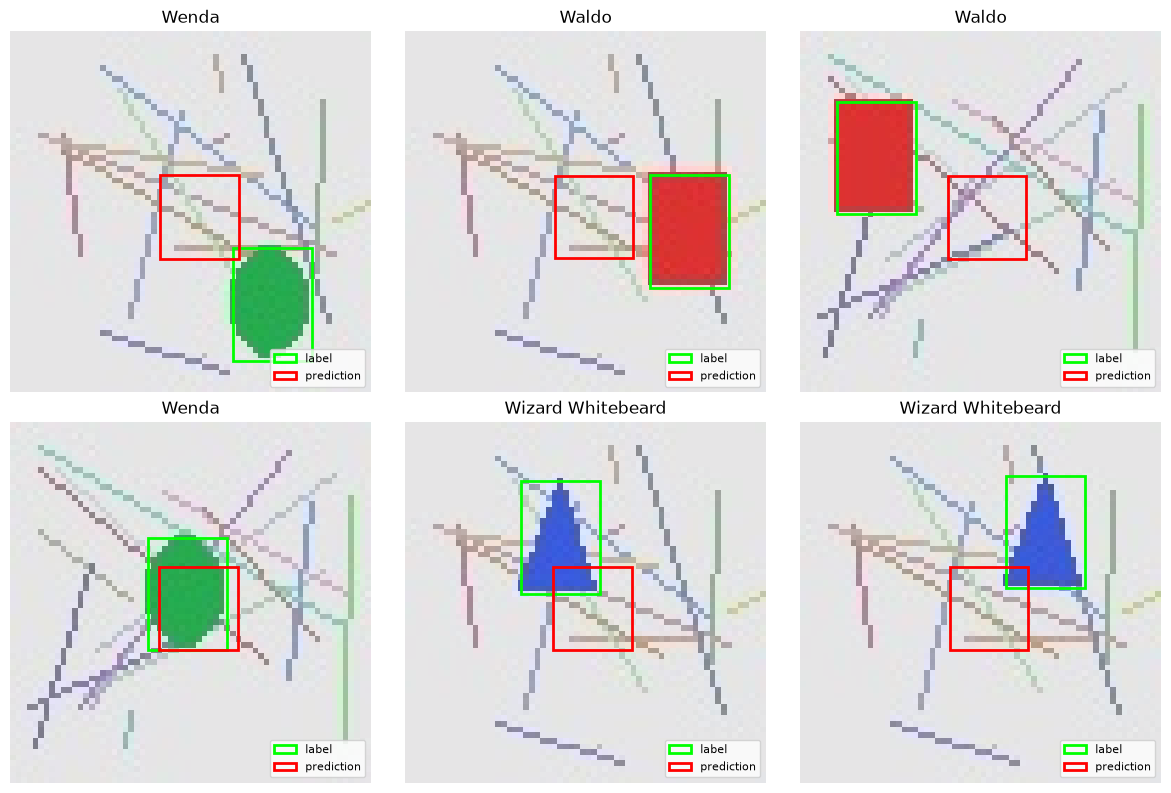

In [5]:
print('EXECUTION CHECK — not the full benchmark' if SMOKE or PILOT else 'Held-out character test results')
print(json.dumps(metrics, indent=2))
test_dataset = ObjectDetectionDataset(DATASET, 'test', size=INPUT_SIZE)
predictions = json.loads((RUN_DIR / 'predictions.json').read_text())
plot_samples(test_dataset, FIGURE_DIR / 'predictions.png', predictions=predictions)
plt.show()

## YOLOv8n reference

YOLOv8n fine-tunes for up to 100 epochs on the same generated data at 640 pixels.
The custom model uses 224 pixels, so this comparison includes resolution and
training-budget differences. It is not a controlled architecture ablation.

Evaluation reloads YOLO's selected `best.pt` and explicitly uses the **test** split.
Native multi-detection metrics are kept separate. For a shared single-object
comparison, the highest-confidence YOLO box is retained (confidence floor 0.001)
and passed to the same evaluator as the custom model. An empty prediction is an
abstention. Smoke mode skips YOLO; it does not verify YOLO training.

In [6]:
yolo_metrics = None
if RUN_YOLO:
    saved_yolo = ARTIFACT_DIR / 'yolo_results.json'
    if REUSE_YOLO and saved_yolo.exists():
        import hashlib
        yolo_metrics = json.loads(saved_yolo.read_text())
        identity = hashlib.sha256((DATASET / 'manifest.json').read_bytes()).hexdigest()
        if (yolo_metrics['dataset_sha256'] != identity or yolo_metrics['seed'] != SEED
            or yolo_metrics['imgsz'] != 640 or yolo_metrics.get('run_mode') != RUN_MODE):
            raise ValueError('Saved YOLO data/settings differ; disable reuse for a new run.')
        print('Reusing the completed YOLO run on this same dataset and settings.')
    else:
        yolo_metrics = train_yolo(DATASET, ROOT / 'outputs/yolo_runs' / RUN_MODE,
                                  epochs=1 if PILOT else 100, size=640, seed=SEED)
    yolo_metrics['run_mode'] = RUN_MODE
    write_json(ARTIFACT_DIR / 'yolo_results.json', yolo_metrics)
    print(json.dumps(yolo_metrics, indent=2))
else:
    print('YOLO training and evaluation not run in smoke mode.')

YOLO training and evaluation not run in smoke mode.


In [7]:
print('RUN_ARTIFACTS_BEGIN')
print(json.dumps({'mode': RUN_MODE, 'custom': metrics, 'history': history, 'yolo': yolo_metrics}))
print('RUN_ARTIFACTS_END')

RUN_ARTIFACTS_BEGIN
{"mode": "smoke", "custom": {"samples": 6, "predictions": 6, "true_positives": 0, "precision": 0.0, "recall": 0.0, "f1": 0.0, "class_accuracy": 0.16666666666666666, "mean_iou": 0.1169511726194012, "map50_all_points": 0.0, "ap50_by_class": {"Waldo": 0.0, "Wenda": 0.0, "Wizard Whitebeard": 0.0}, "iou_threshold": 0.5, "protocol": "one-top-confidence-box-per-image", "forward_ms_per_image": 6.9551500000670785, "timing_scope": "warm forward only; excludes loading, transfers and postprocessing", "device": "cpu", "config": {"dataset_sha256": "31ab214f9a8f8756bad07eaa9f03744b5f6ec88d8db96732f8e45b338e03242f", "size": 64, "seed": 42, "pretrained": false, "batch_size": 6, "patience": 5, "architecture": "resnet18-spatial4-layernorm-validbox-v2"}, "epochs_completed": 2, "selected_epoch": 2, "parameters": 13423431, "torch_version": "2.14.0+cpu", "run_mode": "smoke", "benchmark_result": false}, "history": [{"epoch": 1, "train": {"total": 1.21999192237854, "classification": 1.17665

## Interpretation and reproducibility

Use a fresh full run before making claims about character detection accuracy.
The old notebook's metrics cannot validate this revision: its class-0 filtering,
shared backgrounds and validation-only YOLO scores changed what was measured.

The experiment still has a narrow scope: three fixed cut-outs, one object per
image, no negative scenes, no occlusion and fixed object scale. New backgrounds
alone do not establish generalization to new poses or real scenes.

Run `python scripts/build_report.py` after execution and `quarto render` to update
the local report. Smoke artifacts are kept separately and cannot populate the
benchmark comparison. The repository stays private until the full experiment
has been reviewed.